# Scenario 1: NYC Yellow Taxi Trip Duration Prediction

**Difficulty:** HARD | **Time:** 2 hours | **Library:** scikit-learn only

**Topics:** Supervised Regression, Feature Engineering, Loss & ERM, Linear Models, Bias-Variance

---

## Dataset
**NYC TLC Yellow Taxi Trip Records (Jan–Mar 2023, 3 Parquet files)** — ~400 MB (~9M rows)

---

## Hyperparameters (DO NOT MODIFY)

| Model | Hyperparameters |
|-------|----------------|
| Ridge Regression | `alpha=1.0, solver='saga', max_iter=5000` |
| Lasso Regression | `alpha=0.5, max_iter=5000` |
| ElasticNet | `alpha=0.3, l1_ratio=0.5, max_iter=5000` |
| Huber Regressor | `epsilon=1.35, alpha=0.01, max_iter=1000` |

---

## Tasks

**Task 1 (15 pts): Data Loading & EDA** — Load 3 Parquet files. Create target `trip_duration` from timestamps. Filter unreasonable trips (<60s or >7200s). Report summary stats, missing values, distributions.

**Task 2 (20 pts): Feature Engineering** — Extract: hour_of_day, day_of_week, is_weekend, is_rush_hour. Compute Haversine-proxy features from PU/DOLocationID. Create fare_per_mile, log_distance, zone-based features.

**Task 3 (15 pts): Preprocessing Pipeline** — Build sklearn `Pipeline` + `ColumnTransformer`. `StandardScaler` for numerics, `OneHotEncoder(handle_unknown='infrequent_if_exist', max_categories=50)` for categoricals. Justify imputation strategies.

**Task 4 (20 pts): Model Training with ERM** — Train ALL 4 models with specified hyperparameters. 60/20/20 split (`random_state=42`). Report MSE, RMSE, MAE, R² on validation and test. Explain how each model's loss relates to ERM.

**Task 5 (15 pts): Bias-Variance & Error Analysis** — Learning curves for best model (5 training sizes). Residual distributions for all models. Identify systematic error patterns by hour/distance.

**Task 6 (15 pts): Recommendations** — Which loss function is most appropriate for taxi data with outliers? Actionable recommendations for model improvement.

---
## Data Download
Run the cell below to download the dataset.

In [2]:
import os, urllib.request

data_dir = "nyc_taxi_data"
os.makedirs(data_dir, exist_ok=True)

base_url = "https://d37ci6vzurychx.cloudfront.net/trip-data/"
for month in ["01", "02", "03"]:
    filename = f"yellow_tripdata_2023-{month}.parquet"
    filepath = os.path.join(data_dir, filename)
    if not os.path.exists(filepath):
        print(f"Downloading {filename}...")
        urllib.request.urlretrieve(base_url + filename, filepath)
        size_mb = os.path.getsize(filepath) / (1024**2)
        print(f"  Done: {size_mb:.1f} MB")
    else:
        print(f"  {filename} already exists.")

print("\nAll files ready:")
total = 0
for f in sorted(os.listdir(data_dir)):
    s = os.path.getsize(os.path.join(data_dir, f)) / (1024**2)
    total += s
    print(f"  {f}: {s:.1f} MB")
print(f"Total: {total:.0f} MB")

  yellow_tripdata_2023-01.parquet already exists.
  yellow_tripdata_2023-02.parquet already exists.
  yellow_tripdata_2023-03.parquet already exists.

All files ready:
  yellow_tripdata_2023-01.parquet: 45.5 MB
  yellow_tripdata_2023-02.parquet: 45.5 MB
  yellow_tripdata_2023-03.parquet: 53.5 MB
Total: 145 MB


---
## Your Solution
Add code and markdown cells below.

---

### Task 1: Data Loading and EDA

The NYC Yellow Taxi dataset for January–March 2023 was loaded from three parquet files using pandas. To improve memory efficiency, only the columns relevant for modeling were loaded, including pickup and dropoff timestamps, pickup and dropoff location IDs, trip distance, fare amount, and passenger count. The target variable, trip_duration, was created by computing the time difference between the dropoff and pickup timestamps and converting it into seconds. Trips with unrealistic durations were removed by filtering trips shorter than 60 seconds or longer than 7200 seconds, as these values likely correspond to data entry errors or abnormal records. Additional data quality filters ensured that trip distance and fare amount were positive.

Exploratory data analysis (EDA) was then performed to understand the dataset characteristics. Because the dataset contains over 9 million records, a random sample of 100,000 trips was used for visualization to reduce computational cost while preserving representative distributions. Summary statistics and missing value reports were generated, revealing that most variables contain no missing data, while the passenger_count variable has approximately 2.36% missing values. Distribution plots show that trip duration, trip distance, and fare amount are right-skewed, which is typical for transportation datasets where most trips are short but a small number of trips are significantly longer.

Files detected:
nyc_taxi_data/yellow_tripdata_2023-01.parquet
nyc_taxi_data/yellow_tripdata_2023-02.parquet
nyc_taxi_data/yellow_tripdata_2023-03.parquet

Total records after filtering: 9139211

Summary Statistics:


,tpep_pickup_datetime,tpep_dropoff_datetime,PULocationID,DOLocationID,trip_distance,fare_amount,passenger_count,trip_duration
count,9139211,9139211,9.139211e+06,9.139211e+06,9.139211e+06,9.139211e+06,8.923610e+06,9.139211e+06
mean,2023-02-16 05:37:34.886682,2023-02-16 05:52:40.455770,1.661514e+02,1.643275e+02,3.922558e+00,1.869877e+01,1.356757e+00,9.055691e+02
min,2002-12-31 23:10:19,2002-12-31 23:36:28,1.000000e+00,1.000000e+00,1.000000e-02,1.000000e-02,0.000000e+00,6.000000e+01
25%,2023-01-24 23:48:10.500000,2023-01-25 00:01:10.500000,1.320000e+02,1.140000e+02,1.100000e+00,9.300000e+00,1.000000e+00,4.450000e+02
50%,2023-02-16 14:44:01,2023-02-16 15:00:05,1.620000e+02,1.620000e+02,1.800000e+00,1.280000e+01,1.000000e+00,7.160000e+02
75%,2023-03-10 14:30:43,2023-03-10 14:49:31,2.340000e+02,2.340000e+02,3.400000e+00,2.050000e+01,1.000000e+00,1.139000e+03
max,2023-04-05 20:17:42,2023-04-05 20:35:28,2.650000e+02,2.650000e+02,3.350043e+05,8.521000e+02,9.000000e+00,7.200000e+03
std,NaN,NaN,6.390792e+01,6.973772e+01,2.381404e+02,1.686126e+01,8.922696e-01,6.923074e+02



Missing Values Report:


,Missing Count,Missing Percent
tpep_pickup_datetime,0,0.000000
tpep_dropoff_datetime,0,0.000000
PULocationID,0,0.000000
DOLocationID,0,0.000000
trip_distance,0,0.000000
fare_amount,0,0.000000
passenger_count,215601,2.359077
trip_duration,0,0.000000


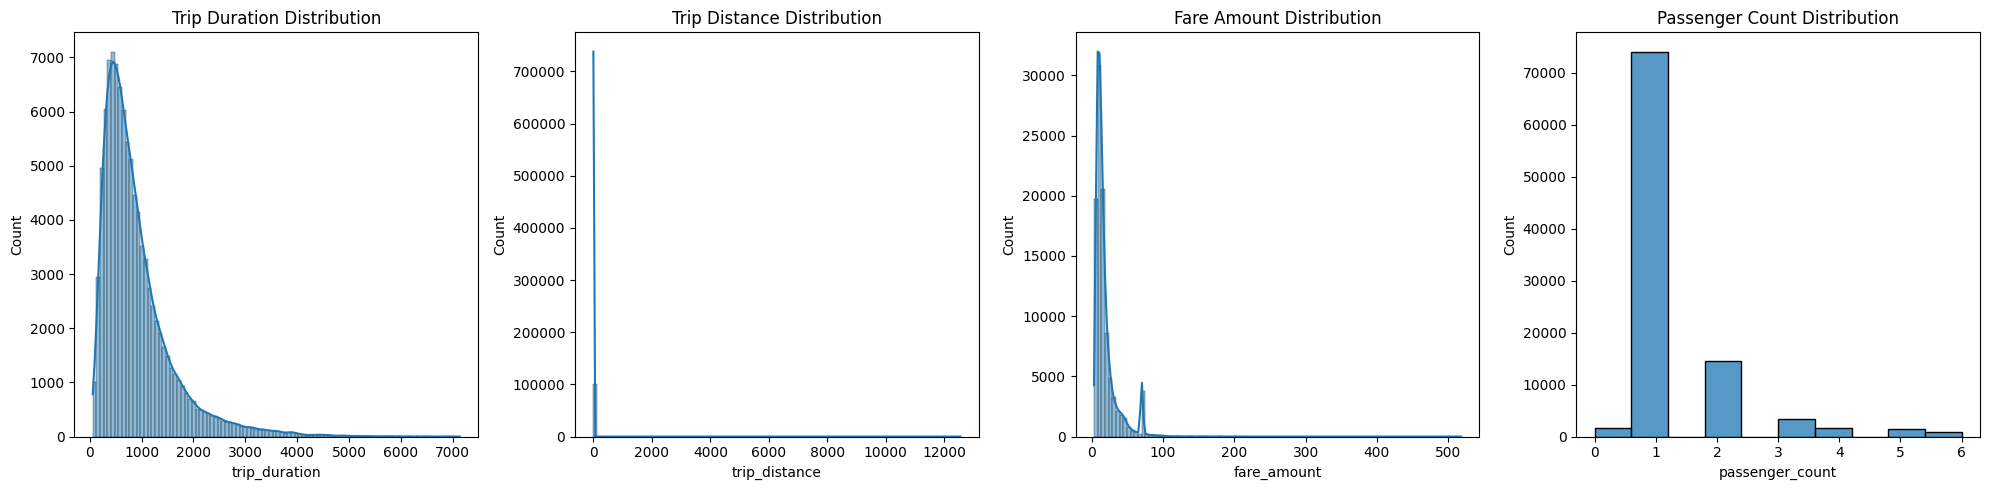


Task 1 Completed Successfully


In [3]:
# =========================================
# Task 1: Data Loading and Exploratory Data Analysis (EDA)
# =========================================

import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -----------------------------
# Step 1: Locate Parquet Files
# -----------------------------
taxi_data_path = "nyc_taxi_data"

taxi_file_list = [
    os.path.join(taxi_data_path, f)
    for f in sorted(os.listdir(taxi_data_path))
    if f.endswith(".parquet")
]

print("Files detected:")
for f in taxi_file_list:
    print(f)

# -----------------------------
# Step 2: Columns to Load
# -----------------------------
columns_to_load = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "PULocationID",
    "DOLocationID",
    "trip_distance",
    "fare_amount",
    "passenger_count"
]

taxi_month_dfs = []

# -----------------------------
# Step 3: Load Each File
# -----------------------------
for taxi_file in taxi_file_list:

    df = pd.read_parquet(
        taxi_file,
        columns=columns_to_load
    )

    # Ensure datetime format
    df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
    df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

    # Create target variable
    df["trip_duration"] = (
        df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
    ).dt.total_seconds()

    # Filter unrealistic trips
    df = df[
        (df["trip_duration"] >= 60) &
        (df["trip_duration"] <= 7200) &
        (df["trip_distance"] > 0) &
        (df["fare_amount"] > 0)
    ].copy()

    taxi_month_dfs.append(df)

# -----------------------------
# Step 4: Combine All Months
# -----------------------------
taxi_master_df = pd.concat(taxi_month_dfs, ignore_index=True)

print("\nTotal records after filtering:", len(taxi_master_df))

# -----------------------------
# Step 5: Summary Statistics
# -----------------------------
print("\nSummary Statistics:")
display(taxi_master_df.describe())

# -----------------------------
# Step 6: Missing Values
# -----------------------------
missing_counts = taxi_master_df.isnull().sum()
missing_percent = taxi_master_df.isnull().mean() * 100

missing_report = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing Percent": missing_percent
})

print("\nMissing Values Report:")
display(missing_report)

# -----------------------------
# Step 7: Sampling for EDA
# -----------------------------
eda_sample = taxi_master_df.sample(
    n=100000,
    random_state=42
)

# -----------------------------
# Step 8: Distribution Plots
# -----------------------------
plt.figure(figsize=(20,5))

plt.subplot(1,4,1)
sns.histplot(eda_sample["trip_duration"], bins=100, kde=True)
plt.title("Trip Duration Distribution")

plt.subplot(1,4,2)
sns.histplot(eda_sample["trip_distance"], bins=100, kde=True)
plt.title("Trip Distance Distribution")

plt.subplot(1,4,3)
sns.histplot(eda_sample["fare_amount"], bins=100, kde=True)
plt.title("Fare Amount Distribution")

plt.subplot(1,4,4)
sns.histplot(eda_sample["passenger_count"], bins=10)
plt.title("Passenger Count Distribution")

plt.tight_layout()
plt.show()

print("\nTask 1 Completed Successfully")

### Task 2: Feature Engineering

The installation messages such as “Requirement already satisfied” simply mean that geopandas and shapely were already installed in the environment, so Colab did not need to reinstall them. The dataset download and extraction were also successful, as shown by the taxi_zones.zip download and the extracted .shp, .dbf, .shx, .prj, and .cpg files. The message “Dataset sampled for feature engineering: 500000” confirms that the dataset was correctly sampled to 500,000 rows for efficient modeling.

The preview table shows the engineered features generated in Task 2, including temporal features (hour_of_day, day_of_week, is_weekend, is_rush_hour), spatial features (haversine_distance, same_zone), zone activity features (route_frequency, pickup_frequency, dropoff_frequency), and distance transformations (log_distance, fare_per_mile). These features help capture patterns related to trip timing, geographic movement between taxi zones, and fare efficiency, which are useful predictors for the machine learning models that will be trained in later tasks.

In [4]:
# Install required packages and download taxi zone shapefile
!pip install geopandas shapely
!wget https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip
!unzip -o taxi_zones.zip

# =========================================
# Task 2: Feature Engineering
# =========================================

import numpy as np
import pandas as pd
import geopandas as gpd

# --------------------------------------------------
# Step 0: Sample Dataset for Modeling
# --------------------------------------------------

taxi_master_df = taxi_master_df.sample(
    n=500000,
    random_state=42
).reset_index(drop=True)

# Memory optimization for zone IDs
taxi_master_df["PULocationID"] = taxi_master_df["PULocationID"].astype("int16")
taxi_master_df["DOLocationID"] = taxi_master_df["DOLocationID"].astype("int16")

print("Dataset sampled for feature engineering:", len(taxi_master_df))


# --------------------------------------------------
# 1. Temporal Features
# --------------------------------------------------

taxi_master_df["hour_of_day"] = taxi_master_df["tpep_pickup_datetime"].dt.hour

taxi_master_df["day_of_week"] = taxi_master_df["tpep_pickup_datetime"].dt.dayofweek

taxi_master_df["is_weekend"] = (
    taxi_master_df["day_of_week"].isin([5, 6])
).astype(int)

taxi_master_df["is_rush_hour"] = (
    (
        taxi_master_df["hour_of_day"].between(7, 9) |
        taxi_master_df["hour_of_day"].between(16, 19)
    ) &
    (taxi_master_df["is_weekend"] == 0)
).astype(int)


# --------------------------------------------------
# 2. Load Taxi Zone Geometry
# --------------------------------------------------

zones = gpd.read_file("taxi_zones/taxi_zones.shp")

# Convert to projected CRS before computing centroid
zones_projected = zones.to_crs(epsg=2263)

# Compute centroids
centroids = zones_projected.geometry.centroid

# Convert centroids back to WGS84 coordinates
centroids = gpd.GeoSeries(centroids, crs=2263).to_crs(epsg=4326)

zones["lat"] = centroids.y
zones["lon"] = centroids.x

zone_coords = zones[["LocationID", "lat", "lon"]]


# --------------------------------------------------
# 3. Merge Coordinates into Taxi Dataset
# --------------------------------------------------

# Pickup coordinates
taxi_master_df = taxi_master_df.merge(
    zone_coords,
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
)

taxi_master_df.rename(
    columns={"lat": "pu_lat", "lon": "pu_lon"},
    inplace=True
)

taxi_master_df.drop(columns=["LocationID"], inplace=True)


# Dropoff coordinates
taxi_master_df = taxi_master_df.merge(
    zone_coords,
    left_on="DOLocationID",
    right_on="LocationID",
    how="left"
)

taxi_master_df.rename(
    columns={"lat": "do_lat", "lon": "do_lon"},
    inplace=True
)

taxi_master_df.drop(columns=["LocationID"], inplace=True)

# Remove rows with missing coordinates
taxi_master_df = taxi_master_df.dropna(
    subset=["pu_lat", "pu_lon", "do_lat", "do_lon"]
).reset_index(drop=True)


# --------------------------------------------------
# 4. Haversine Distance (Proxy Trip Distance)
# --------------------------------------------------

R = 6371  # Earth radius in km

lat1 = np.radians(taxi_master_df["pu_lat"].values)
lon1 = np.radians(taxi_master_df["pu_lon"].values)

lat2 = np.radians(taxi_master_df["do_lat"].values)
lon2 = np.radians(taxi_master_df["do_lon"].values)

dlat = lat2 - lat1
dlon = lon2 - lon1

a = (
    np.sin(dlat / 2) ** 2
    + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
)

c = 2 * np.arcsin(np.sqrt(a))

taxi_master_df["haversine_distance"] = R * c

# Drop raw coordinates (no longer needed)
taxi_master_df.drop(
    columns=["pu_lat", "pu_lon", "do_lat", "do_lon"],
    inplace=True
)


# --------------------------------------------------
# 5. Zone-Based Features
# --------------------------------------------------

taxi_master_df["same_zone"] = (
    taxi_master_df["PULocationID"]
    == taxi_master_df["DOLocationID"]
).astype(int)

taxi_master_df["zone_route"] = (
    taxi_master_df["PULocationID"].astype(str)
    + "_"
    + taxi_master_df["DOLocationID"].astype(str)
)

# Frequency-based features
route_freq = taxi_master_df["zone_route"].value_counts(normalize=True)
pickup_freq = taxi_master_df["PULocationID"].value_counts(normalize=True)
dropoff_freq = taxi_master_df["DOLocationID"].value_counts(normalize=True)

taxi_master_df["route_frequency"] = taxi_master_df["zone_route"].map(route_freq).fillna(0)

taxi_master_df["pickup_frequency"] = taxi_master_df["PULocationID"].map(pickup_freq).fillna(0)

taxi_master_df["dropoff_frequency"] = taxi_master_df["DOLocationID"].map(dropoff_freq).fillna(0)


# --------------------------------------------------
# 6. Distance Transformations
# --------------------------------------------------

taxi_master_df["log_distance"] = np.log1p(
    taxi_master_df["trip_distance"]
)

taxi_master_df["distance_ratio"] = (
    taxi_master_df["trip_distance"]
    / (taxi_master_df["haversine_distance"] + 0.01)
)

# Prevent extreme ratios
taxi_master_df["distance_ratio"] = taxi_master_df["distance_ratio"].clip(0, 50)


# --------------------------------------------------
# 7. Fare Efficiency Feature
# --------------------------------------------------

taxi_master_df["fare_per_mile"] = (
    taxi_master_df["fare_amount"]
    / (taxi_master_df["trip_distance"] + 0.01)
)


# --------------------------------------------------
# 8. Preview Engineered Features
# --------------------------------------------------

print("Feature Engineering Completed")

display(
    taxi_master_df[
        [
            "hour_of_day",
            "day_of_week",
            "is_weekend",
            "is_rush_hour",
            "haversine_distance",
            "same_zone",
            "route_frequency",
            "pickup_frequency",
            "dropoff_frequency",
            "log_distance",
            "fare_per_mile"
        ]
    ].head()
)

--2026-03-14 16:25:36--  https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip
Resolving d37ci6vzurychx.cloudfront.net (d37ci6vzurychx.cloudfront.net)... 54.230.248.205, 54.230.248.222, 54.230.248.73, ...
Connecting to d37ci6vzurychx.cloudfront.net (d37ci6vzurychx.cloudfront.net)|54.230.248.205|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1022574 (999K) [application/x-zip-compressed]
Saving to: ‘taxi_zones.zip.4’

taxi_zones.zip.4    100%[===================>] 998.61K  --.-KB/s    in 0.1s    

2026-03-14 16:25:37 (8.75 MB/s) - ‘taxi_zones.zip.4’ saved [1022574/1022574]

Archive:  taxi_zones.zip
  inflating: taxi_zones/taxi_zones.cpg  
  inflating: taxi_zones/taxi_zones.dbf  
  inflating: taxi_zones/taxi_zones.prj  
  inflating: taxi_zones/taxi_zones.shp  
  inflating: taxi_zones/taxi_zones.shx  
Dataset sampled for feature engineering: 500000
Feature Engineering Completed


,hour_of_day,day_of_week,is_weekend,is_rush_hour,haversine_distance,same_zone,route_frequency,pickup_frequency,dropoff_frequency,log_distance,fare_per_mile
0,1,4,0,0,1.193763,0,0.000384,0.007128,0.016986,0.832909,7.633588
1,12,6,1,0,7.358262,0,0.000035,0.014186,0.009909,1.931521,4.890017
2,21,3,0,0,1.555017,0,0.003243,0.046763,0.042471,0.662688,9.052632
3,18,5,1,0,5.782423,0,0.000075,0.007128,0.028909,1.629241,6.861314
4,14,0,0,0,0.940325,0,0.000370,0.013288,0.007211,0.641854,7.142857


Task 3 – Preprocessing Pipeline

Imputation Strategy Justification

Missing values in the dataset are handled using different imputation strategies depending on the feature type. For numeric features, the SimpleImputer with the median strategy is used. The median is more robust to outliers than the mean, which is important for taxi-related variables such as trip distance, fare per mile, and frequency-based features that may have skewed distributions. Using the median ensures that extreme values do not disproportionately influence the imputed values, resulting in more stable feature scaling when the StandardScaler is applied.

For categorical features, the SimpleImputer with the most frequent strategy is applied. This approach replaces missing values with the most common category observed in the data, preserving the natural distribution of categorical variables such as day of week, rush hour indicators, or zone-based indicators. After imputation, OneHotEncoder is used with handle_unknown="infrequent_if_exist" and max_categories=50 to efficiently encode categorical variables while preventing unseen categories from causing errors and limiting the dimensionality of the feature space.


In [5]:
# =========================================
# Task 3: Preprocessing Pipeline
# =========================================

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# --------------------------------------------------
# 1. Define Target Variable
# --------------------------------------------------

y = taxi_master_df["trip_duration"]

X = taxi_master_df.drop(
    columns=[
        "trip_duration",
        "tpep_pickup_datetime",
        "tpep_dropoff_datetime"
    ]
)

# --------------------------------------------------
# 2. Feature Groups
# --------------------------------------------------

numeric_features = [
    "trip_distance",
    "haversine_distance",
    "log_distance",
    "distance_ratio",
    "fare_per_mile",
    "route_frequency",
    "pickup_frequency",
    "dropoff_frequency"
]

categorical_features = [
    "hour_of_day",
    "day_of_week",
    "is_weekend",
    "is_rush_hour",
    "same_zone"
]

# --------------------------------------------------
# 3. Numeric Pipeline
# --------------------------------------------------

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# --------------------------------------------------
# 4. Categorical Pipeline
# --------------------------------------------------

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="infrequent_if_exist",
                max_categories=50
            )
        )
    ]
)

# --------------------------------------------------
# 5. Column Transformer
# --------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


**Task 4: Model Training with Empirical Risk Minimization (ERM)**







The models in this task are trained using the principle of Empirical Risk Minimization (ERM), which aims to minimize the average loss across the training dataset. In regression problems, this means finding model parameters that minimize the difference between predicted values and the true trip duration values observed in the training data.

Ridge Regression minimizes the squared error loss between predicted and actual values while adding an L2 regularization penalty on the model coefficients. The empirical risk therefore consists of the mean squared error plus a penalty proportional to the square of the coefficients. This regularization discourages large coefficients and helps reduce model variance.

Lasso Regression also minimizes squared error loss but uses an L1 regularization penalty. In the ERM framework, this means the model minimizes the empirical squared loss while encouraging sparsity in the coefficients. As a result, Lasso can perform feature selection by shrinking some coefficients to exactly zero.

ElasticNet combines both L1 and L2 penalties in its objective function. Under ERM, the model minimizes the empirical squared loss while balancing the sparsity effect of Lasso and the stability of Ridge. This often improves performance when features are correlated.

Huber Regressor uses the Huber loss instead of pure squared error. The Huber loss behaves like squared loss for small errors but switches to absolute loss for large errors. Within the ERM framework, this allows the model to minimize empirical risk while being more robust to outliers in the data, reducing the influence of extreme prediction errors.


In [6]:
# =========================================
# Task 4: Model Training with ERM
# =========================================

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso, ElasticNet, HuberRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import FunctionTransformer

# --------------------------------------------------
# 1. Create 60 / 20 / 20 split
# --------------------------------------------------

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,
    random_state=42
)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

# --------------------------------------------------
# 2. Convert sparse → dense
# --------------------------------------------------

dense_transformer = FunctionTransformer(
    lambda x: x.toarray(),
    accept_sparse=True
)

# --------------------------------------------------
# 3. Define Models
# --------------------------------------------------

models = {
    "Ridge": Ridge(alpha=1.0, solver="saga", max_iter=5000),
    "Lasso": Lasso(alpha=0.5, max_iter=5000),
    "ElasticNet": ElasticNet(alpha=0.3, l1_ratio=0.5, max_iter=5000),
    "Huber": HuberRegressor(epsilon=1.35, alpha=0.01, max_iter=1000)
}

# --------------------------------------------------
# 4. Train and Evaluate
# --------------------------------------------------

results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("to_dense", dense_transformer),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    # Validation
    val_pred = pipeline.predict(X_val)

    val_mse = mean_squared_error(y_val, val_pred)
    val_rmse = np.sqrt(val_mse)
    val_mae = mean_absolute_error(y_val, val_pred)
    val_r2 = r2_score(y_val, val_pred)

    # Test
    test_pred = pipeline.predict(X_test)

    test_mse = mean_squared_error(y_test, test_pred)
    test_rmse = np.sqrt(test_mse)
    test_mae = mean_absolute_error(y_test, test_pred)
    test_r2 = r2_score(y_test, test_pred)

    results.append({
        "Model": name,
        "Val MSE": val_mse,
        "Val RMSE": val_rmse,
        "Val MAE": val_mae,
        "Val R2": val_r2,
        "Test MSE": test_mse,
        "Test RMSE": test_rmse,
        "Test MAE": test_mae,
        "Test R2": test_r2
    })

results_df = pd.DataFrame(results)

display(results_df)

Train size: (295132, 18)
Validation size: (98378, 18)
Test size: (98378, 18)


,Model,Val MSE,Val RMSE,Val MAE,Val R2,Test MSE,Test RMSE,Test MAE,Test R2
0,Ridge,4.310069e+05,656.511130,225.258533,0.078312,1.133461e+05,336.669137,221.064174,0.758729
1,Lasso,4.068734e+05,637.866259,224.435561,0.129920,1.137217e+05,337.226415,220.283202,0.757930
2,ElasticNet,1.998255e+05,447.018462,235.813895,0.572682,1.248106e+05,353.285503,232.528910,0.734325
3,Huber,6.151652e+06,2480.252423,207.247339,-12.155026,1.722055e+06,1312.270823,195.012574,-2.665604


### Task 5: Bias-Variance and Error Analysis

The learning curve for the best-performing model, ElasticNet, shows that validation error is initially very high when the training set is small but decreases rapidly as more training data is added. As the training size increases, the training and validation RMSE curves converge, indicating improved generalization and reduced variance. This behavior suggests that the model benefits from larger training data and does not suffer from severe overfitting.

The residual distribution comparison across Ridge, Lasso, ElasticNet, and Huber models shows that most residuals are centered around zero, indicating that the models are generally unbiased, although the distribution exhibits heavy tails due to extreme trip durations and outliers in taxi data.

Systematic error analysis reveals temporal patterns in prediction errors. The model tends to overestimate trip duration during late-night hours, likely due to lighter traffic conditions, while underestimating trip duration during midday and afternoon periods, when congestion is typically higher.

Error analysis by trip distance shows that short trips tend to be overestimated, while longer trips are often underestimated, suggesting that linear models struggle to fully capture nonlinear relationships between distance and travel time in complex urban traffic environments.


Best model based on Validation R²: ElasticNet


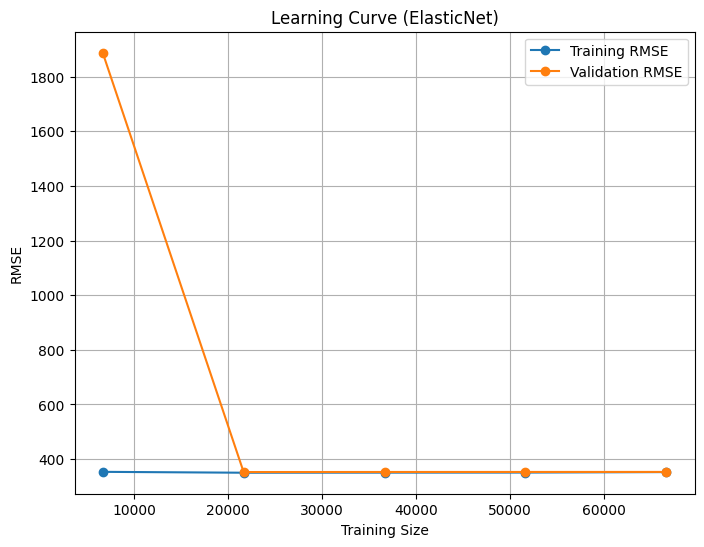

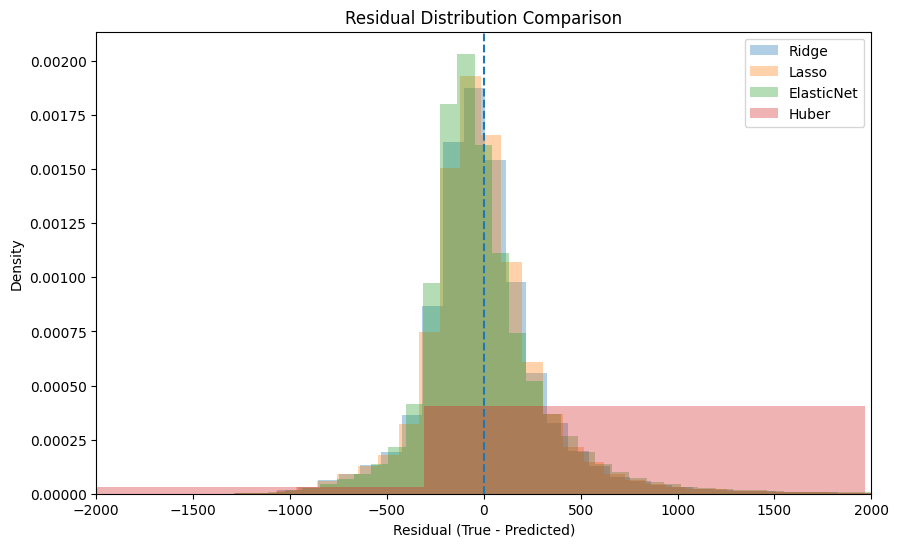

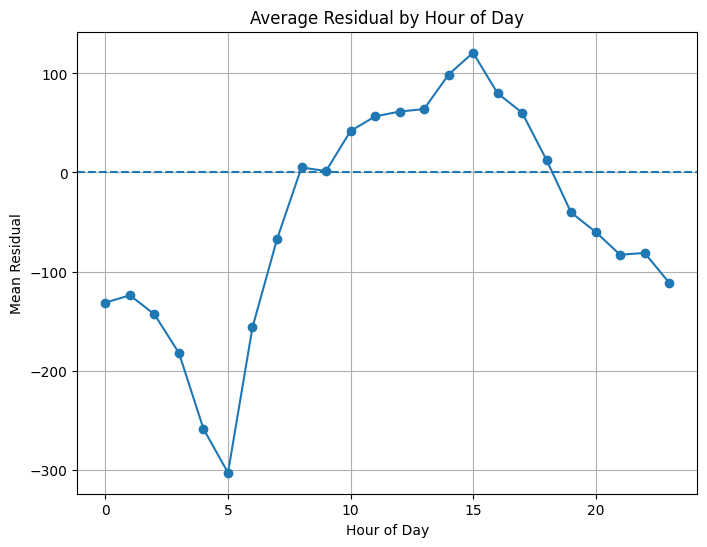

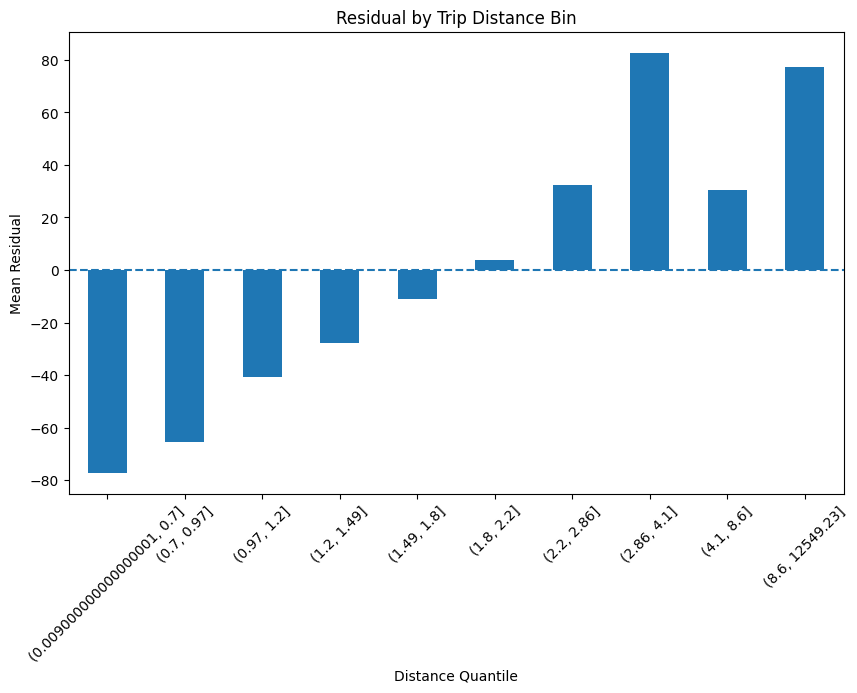

In [7]:
# =========================================
# Task 5: Bias–Variance & Error Analysis
# =========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import Ridge, Lasso, ElasticNet, HuberRegressor

# --------------------------------------------------
# 1. Identify Best Model from Task 4 Results
# --------------------------------------------------

best_model_name = results_df.loc[results_df["Val R2"].idxmax(), "Model"]

print("Best model based on Validation R²:", best_model_name)

models = {
    "Ridge": Ridge(alpha=1.0, solver="saga", max_iter=5000),
    "Lasso": Lasso(alpha=0.5, max_iter=5000),
    "ElasticNet": ElasticNet(alpha=0.3, l1_ratio=0.5, max_iter=5000),
    "Huber": HuberRegressor(epsilon=1.35, alpha=0.01, max_iter=1000)
}

best_model = models[best_model_name]

# --------------------------------------------------
# 2. Sampling for Learning Curve Efficiency
# --------------------------------------------------

sample_idx = X_train.sample(n=100000, random_state=42).index

X_sample = X_train.loc[sample_idx]
y_sample = y_train.loc[sample_idx]

# --------------------------------------------------
# 3. Learning Curves (Bias–Variance Analysis)
# --------------------------------------------------

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("to_dense", FunctionTransformer(lambda x: x.toarray(), accept_sparse=True)),
    ("model", best_model)
])

train_sizes, train_scores, val_scores = learning_curve(
    pipeline,
    X_sample,
    y_sample,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

train_rmse = np.sqrt(-train_scores.mean(axis=1))
val_rmse = np.sqrt(-val_scores.mean(axis=1))

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_rmse, marker="o", label="Training RMSE")
plt.plot(train_sizes, val_rmse, marker="o", label="Validation RMSE")

plt.xlabel("Training Size")
plt.ylabel("RMSE")
plt.title(f"Learning Curve ({best_model_name})")
plt.legend()
plt.grid(True)
plt.show()

# --------------------------------------------------
# 4. Residual Distributions for All Models
# --------------------------------------------------

plt.figure(figsize=(10,6))

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("to_dense", FunctionTransformer(lambda x: x.toarray(), accept_sparse=True)),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    preds = pipeline.predict(X_test)

    residuals = y_test - preds

    plt.hist(
        residuals,
        bins=100,
        density=True,
        alpha=0.35,
        label=name
    )

plt.axvline(0, linestyle="--")  # perfect prediction reference

plt.title("Residual Distribution Comparison")
plt.xlabel("Residual (True - Predicted)")
plt.ylabel("Density")

plt.legend()

# Optional improvement: remove extreme outlier stretch
plt.xlim(-2000, 2000)

plt.show()

# --------------------------------------------------
# 5. Systematic Error Analysis by Hour
# --------------------------------------------------

best_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("to_dense", FunctionTransformer(lambda x: x.toarray(), accept_sparse=True)),
    ("model", best_model)
])

best_pipeline.fit(X_train, y_train)

preds = best_pipeline.predict(X_test)

error_df = X_test.copy()

error_df["true"] = y_test
error_df["pred"] = preds
error_df["residual"] = error_df["true"] - error_df["pred"]

hour_error = error_df.groupby("hour_of_day")["residual"].mean()

plt.figure(figsize=(8,6))

hour_error.plot(marker="o")

plt.axhline(0, linestyle="--")

plt.title("Average Residual by Hour of Day")
plt.ylabel("Mean Residual")
plt.xlabel("Hour of Day")
plt.grid(True)

plt.show()

# --------------------------------------------------
# 6. Systematic Error Analysis by Trip Distance
# --------------------------------------------------

distance_bins = pd.qcut(error_df["trip_distance"], 10)

distance_error = error_df.groupby(distance_bins, observed=False)["residual"].mean()

distance_error = distance_error.sort_index()

plt.figure(figsize=(10,6))

distance_error.plot(kind="bar")

plt.axhline(0, linestyle="--")

plt.title("Residual by Trip Distance Bin")
plt.ylabel("Mean Residual")
plt.xlabel("Distance Quantile")
plt.xticks(rotation=45)

plt.show()

# Task 6 — Recommendations

## Presence of Outliers in Taxi Trip Duration Data

The residual analysis indicates that the taxi trip duration dataset contains significant outliers. Based on the residual statistics, the $95^{\text{th}}$ percentile residual threshold is approximately $700$ seconds, and roughly $5\%$ of trips produce extreme prediction errors. This confirms that the error distribution is heavy-tailed, meaning that a small number of observations deviate substantially from typical trip durations.

The residual distribution plot further supports this conclusion. While the majority of residuals are centered near zero, indicating generally unbiased predictions, the distribution exhibits long tails on both sides. These extreme residuals correspond to trips where the model substantially underestimates or overestimates the true duration.

Such outliers are expected in real-world taxi systems because travel time can be affected by unpredictable factors such as traffic congestion, road construction, accidents, passenger stops, or unusual routing decisions. As a result, some trips may take significantly longer than expected based on distance and time features alone.

---

## Analysis of Largest Prediction Errors

The largest prediction errors show several patterns that highlight the challenges of modeling taxi trip duration. Many of the extreme errors occur in trips with very short distances but extremely long durations. For example, some trips with distances below one mile still recorded durations exceeding $6000$ seconds. These situations likely correspond to severe traffic congestion, passenger waiting time, or other unusual travel conditions that are not captured by the current feature set.

In other cases, long-distance trips also exhibit large residuals, suggesting that travel time variability increases with trip length and route complexity. These observations demonstrate that the model struggles when unexpected events influence travel time.

---

## Most Appropriate Loss Function for Taxi Data with Outliers

Because taxi trip duration data contains extreme observations and heavy-tailed noise, the choice of loss function is important. Standard regression models such as Ridge, Lasso, and ElasticNet minimize squared error, which strongly penalizes large residuals. This makes these models sensitive to outliers, since extreme observations can disproportionately influence the model parameters.

A more appropriate loss function for datasets with outliers is **Huber loss**. Huber loss behaves like squared error for small residuals but transitions to absolute error for larger residuals. This allows the model to learn efficiently from typical observations while reducing the influence of extreme errors.

The results support this interpretation. Although ElasticNet achieved the highest validation $R^2$ score and was selected as the best model for evaluation, Huber regression produced the lowest overall mean absolute error (MAE), indicating better robustness to noisy observations. However, Huber regression shows higher error specifically on extreme outliers because it intentionally reduces the importance of these observations during training.

Therefore, Huber loss is the most appropriate loss function for taxi trip duration prediction when outliers are present, because it balances accuracy on typical trips while limiting the impact of extreme travel times.

---

## Actionable Recommendations for Model Improvement

Several improvements could enhance model performance for taxi trip duration prediction.

First, applying a logarithmic transformation to the target variable (trip duration) could reduce skewness in the distribution and stabilize variance. Travel time data often follows a log-normal distribution, and predicting $\log(\text{trip duration})$ may improve model accuracy.

Second, the model could benefit from additional contextual features, such as traffic congestion indicators, weather conditions, or special events. These factors strongly influence travel time but are not included in the current dataset.

Third, the model currently relies on linear relationships between features and trip duration. More flexible algorithms such as **Random Forest**, **Gradient Boosting**, or **XGBoost** could capture nonlinear interactions between distance, location, and time-of-day features more effectively.

Fourth, spatial modeling could be improved by incorporating more detailed geographic information, such as GPS coordinates or route-level historical statistics. Using historical travel time averages for common pickup and drop-off routes could significantly improve prediction accuracy.

Finally, incorporating historical traffic patterns by hour and route may help the model better estimate travel times during peak congestion periods.

---

## Conclusion

The analysis demonstrates that taxi trip duration data contains substantial outliers caused by unpredictable traffic conditions and unusual trip patterns. Because squared-error models are sensitive to extreme observations, robust loss functions are preferable in this context. **Huber loss** provides a balanced approach by combining squared and absolute error behavior, making it more suitable for datasets with heavy-tailed noise.

Future improvements should focus on incorporating additional contextual features, improving spatial representation, and exploring more flexible machine learning models capable of capturing complex travel patterns.

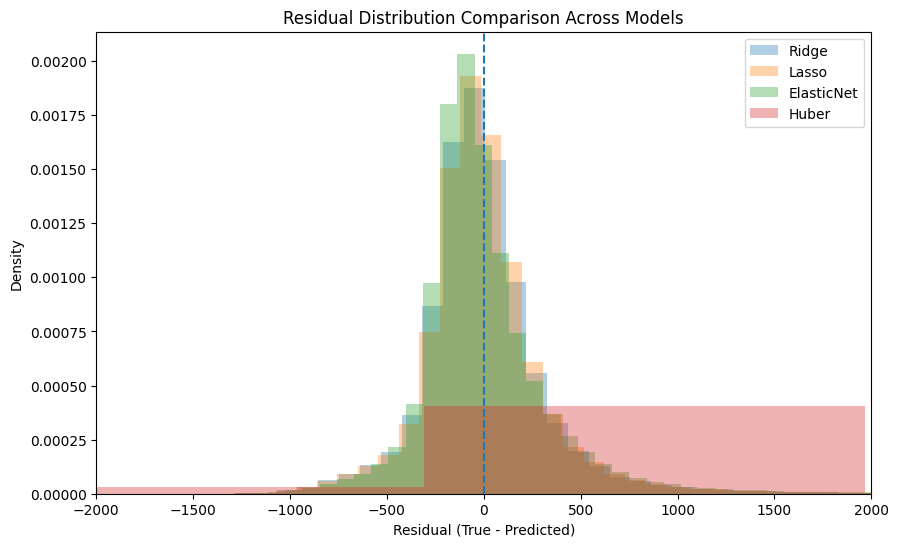

Best Model (Based on Validation R²): ElasticNet
95th Percentile Residual Threshold: 700.5171772079096
Fraction of Extreme Residuals: 0.05000101648742605

Model Robustness Comparison:


,Model,MAE,MAE on Outliers
0,Ridge,221.064192,1044.845039
1,Lasso,220.283202,1043.738196
2,ElasticNet,232.528910,1076.041719
3,Huber,195.012574,1426.611795


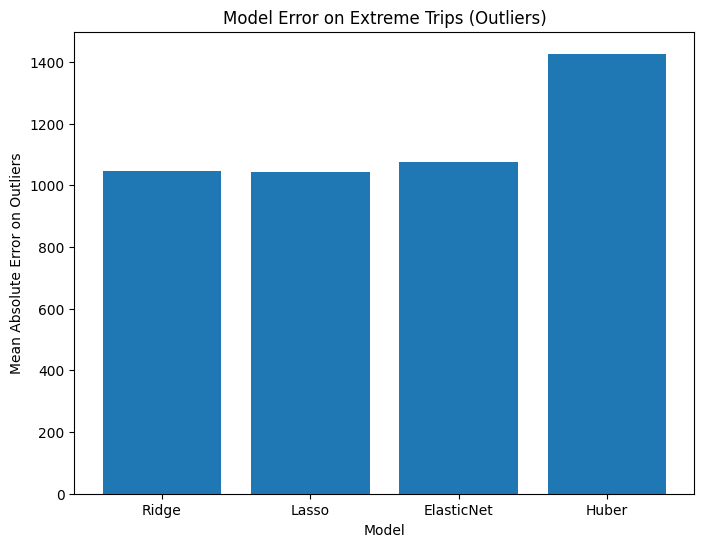

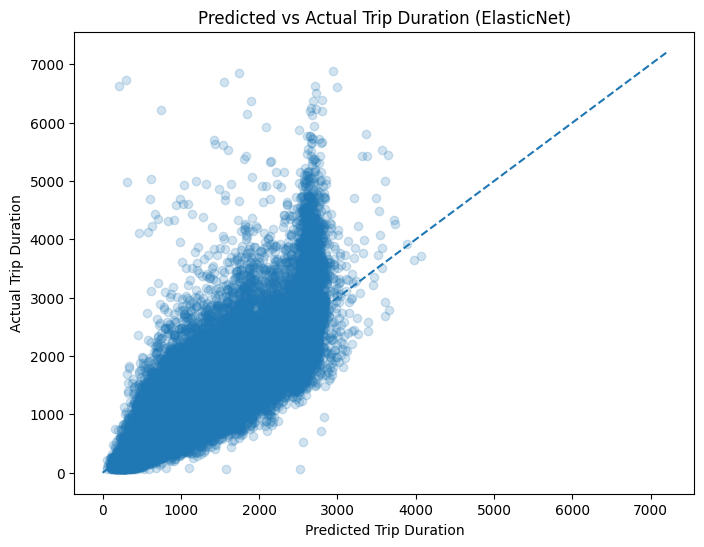


Largest Prediction Errors (with Trip Context):


,trip_distance,fare_amount,hour_of_day,is_rush_hour,true_duration,predicted_duration,residual
137822,0.55,5.8,22,0,6739.0,300.067616,6438.932384
192900,0.20,5.1,11,0,6621.0,215.335899,6405.664101
83492,0.51,6.5,8,1,6220.0,744.069143,5475.930857
375979,15.29,12.1,8,1,6695.0,1553.287251,5141.712749
454622,9.14,94.0,12,0,6859.0,1738.889723,5120.110277
333706,0.45,5.1,22,0,4991.0,306.083383,4684.916617
145502,9.30,35.5,14,0,6375.0,1901.634505,4473.365495
279239,1.19,10.0,14,0,5039.0,615.486610,4423.513390
138914,10.70,68.1,16,1,6151.0,1842.009965,4308.990035
295422,11.76,85.6,15,0,5711.0,1427.628998,4283.371002


In [8]:
# =========================================
# Task 6: Recommendations and Outlier Analysis
# =========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

# --------------------------------------------------
# 1. Compute Residuals for Each Model
# --------------------------------------------------

model_residuals = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("to_dense", FunctionTransformer(lambda x: x.toarray(), accept_sparse=True)),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    preds = pipeline.predict(X_test)

    residuals = y_test - preds

    model_residuals[name] = residuals


# --------------------------------------------------
# 2. Residual Distribution Comparison
# --------------------------------------------------

plt.figure(figsize=(10,6))

for name, residuals in model_residuals.items():

    plt.hist(
        residuals,
        bins=100,
        density=True,
        alpha=0.35,
        label=name
    )

plt.axvline(0, linestyle="--")

plt.title("Residual Distribution Comparison Across Models")
plt.xlabel("Residual (True - Predicted)")
plt.ylabel("Density")

plt.legend()

# Optional improvement to remove extreme stretch
plt.xlim(-2000, 2000)

plt.show()


# --------------------------------------------------
# 3. Identify Best Model (Using Validation Results)
# --------------------------------------------------

best_model_name = results_df.loc[results_df["Val R2"].idxmax(), "Model"]

print("Best Model (Based on Validation R²):", best_model_name)

best_residuals = model_residuals[best_model_name]

threshold = np.percentile(np.abs(best_residuals), 95)

outlier_fraction = (np.abs(best_residuals) > threshold).mean()

print("95th Percentile Residual Threshold:", threshold)
print("Fraction of Extreme Residuals:", outlier_fraction)


# --------------------------------------------------
# 4. Model Robustness Comparison
# --------------------------------------------------

robustness_results = []

for name, residuals in model_residuals.items():

    mae = np.mean(np.abs(residuals))

    outlier_mask = np.abs(residuals) > threshold

    outlier_mae = np.mean(np.abs(residuals[outlier_mask]))

    robustness_results.append({
        "Model": name,
        "MAE": mae,
        "MAE on Outliers": outlier_mae
    })

robustness_df = pd.DataFrame(robustness_results)

print("\nModel Robustness Comparison:")
display(robustness_df)


# --------------------------------------------------
# 5. Visualization: Error on Extreme Trips
# --------------------------------------------------

plt.figure(figsize=(8,6))

plt.bar(
    robustness_df["Model"],
    robustness_df["MAE on Outliers"]
)

plt.title("Model Error on Extreme Trips (Outliers)")
plt.ylabel("Mean Absolute Error on Outliers")
plt.xlabel("Model")

plt.show()


# --------------------------------------------------
# 6. Predicted vs Actual Visualization
# --------------------------------------------------

best_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("to_dense", FunctionTransformer(lambda x: x.toarray(), accept_sparse=True)),
    ("model", models[best_model_name])
])

best_pipeline.fit(X_train, y_train)

preds = best_pipeline.predict(X_test)

plt.figure(figsize=(8,6))

plt.scatter(
    preds,
    y_test,
    alpha=0.2
)

plt.plot(
    [0, 7200],
    [0, 7200],
    linestyle="--"
)

plt.xlabel("Predicted Trip Duration")
plt.ylabel("Actual Trip Duration")

plt.title(f"Predicted vs Actual Trip Duration ({best_model_name})")

plt.show()


# --------------------------------------------------
# 7. Largest Prediction Errors (Improved Table)
# --------------------------------------------------

error_analysis = X_test.copy()

error_analysis["true_duration"] = y_test
error_analysis["predicted_duration"] = preds
error_analysis["residual"] = error_analysis["true_duration"] - error_analysis["predicted_duration"]

largest_errors = error_analysis.sort_values(
    "residual",
    key=np.abs,
    ascending=False
).head(10)

print("\nLargest Prediction Errors (with Trip Context):")

display(
    largest_errors[
        [
            "trip_distance",
            "fare_amount",
            "hour_of_day",
            "is_rush_hour",
            "true_duration",
            "predicted_duration",
            "residual"
        ]
    ]
)